In [2]:
import sys
import os

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

import warnings
warnings.filterwarnings('ignore')

import optuna
import shap
from optuna.samplers import TPESampler

from src.config import RANDOM_STATE
from src.data_loader import load_data, prepare_data
from src.feature_engineering import add_features
from src.models.train import (
    metrics_report,
    objective_catboost,
    objective_xgb,
    objective_lgbm,
    compute_oof_ensemble,
    train_final_models,
)
from src.models.predict import make_submission, make_submission_ensemble
from src.utils import (
    setup_logger,
    save_models,
    plot_feature_importance,
    plot_correlation_matrix,
    plot_target_correlation,
    data_summary,
    check_class_balance,
)

logger = setup_logger('main')

Train shape: (7595, 10)
Test shape: (2532, 9)


,dtype,nulls,nulls_pct,nunique
id,int64,0,0.0,7595
sessions_count,int64,0,0.0,31
avg_session_time,float64,0,0.0,7588
days_since_last_activity,int64,0,0.0,55
purchases_count,int64,0,0.0,19
avg_purchase_value,float64,0,0.0,7444
active_days,int64,0,0.0,23
session_std,float64,0,0.0,7574
is_weekend_user,int64,0,0.0,2
retention,int64,0,0.0,2


,dtype,nulls,nulls_pct,nunique
id,int64,0,0.0,2532
sessions_count,int64,0,0.0,28
avg_session_time,float64,0,0.0,2527
days_since_last_activity,int64,0,0.0,51
purchases_count,int64,0,0.0,17
avg_purchase_value,float64,0,0.0,2478
active_days,int64,0,0.0,22
session_std,float64,0,0.0,2521
is_weekend_user,int64,0,0.0,2


Распределение классов:
  Класс 1: 5561 (73.2%)
  Класс 0: 2034 (26.8%)
Соотношение: 2.73
Сбалансирован: Нет


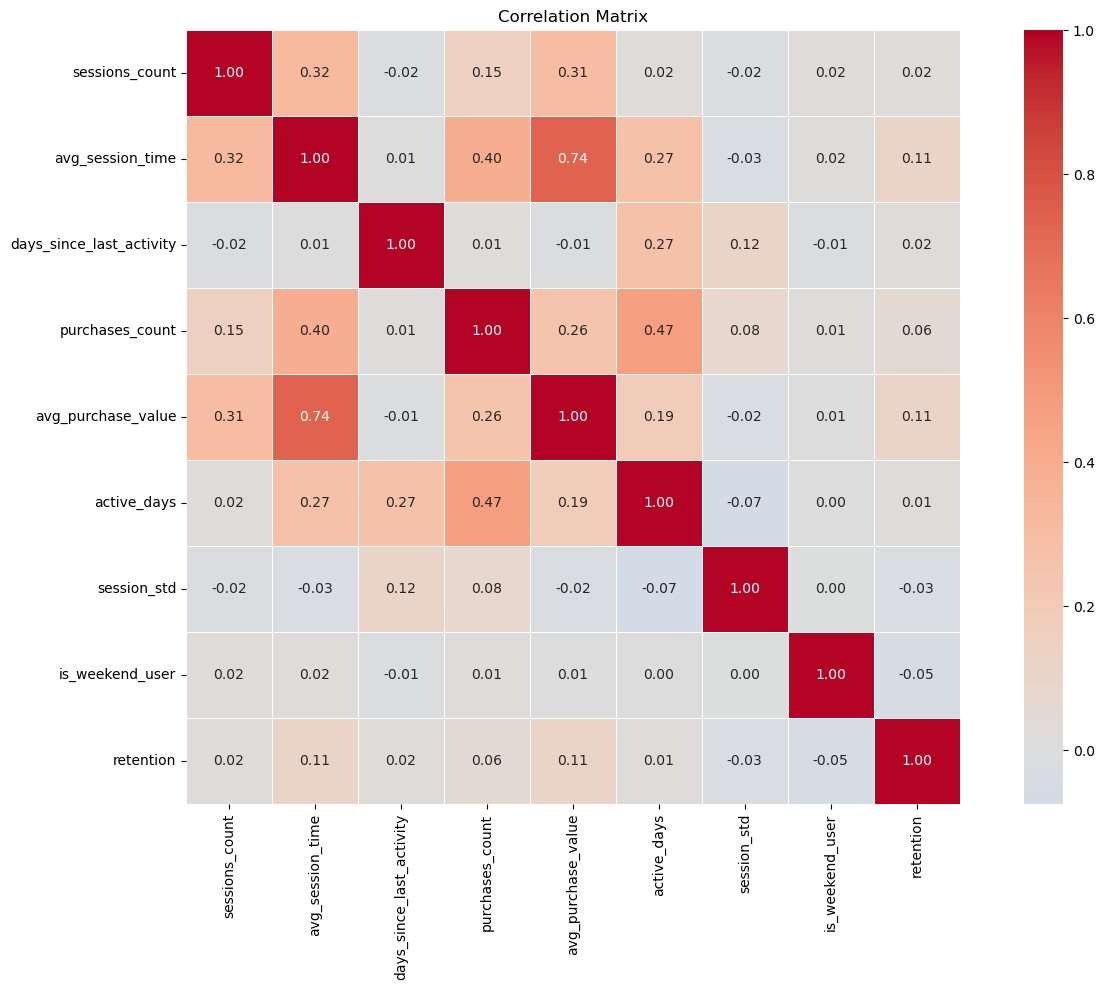

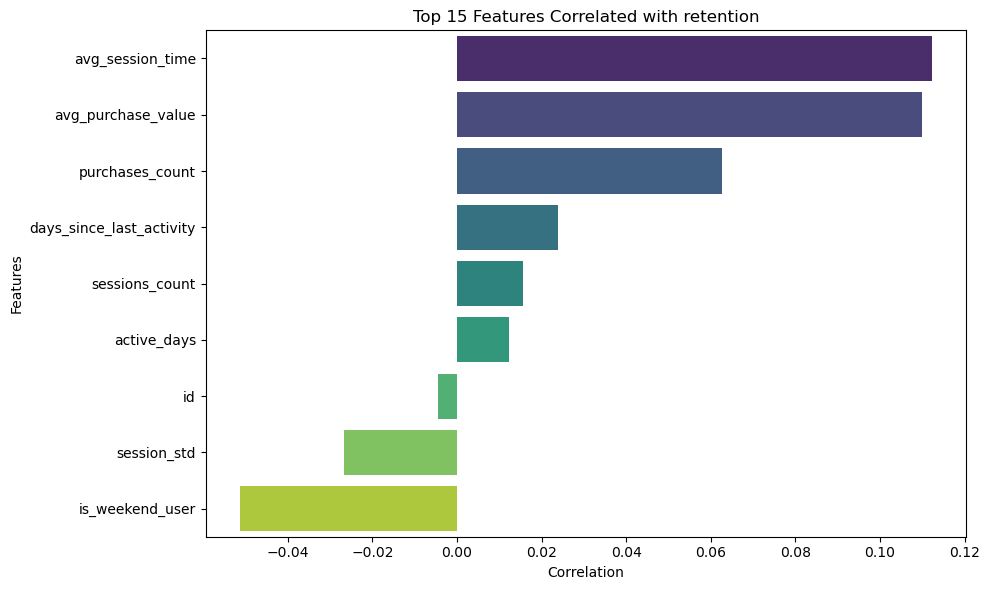

In [3]:
df_train, df_test = load_data()

# Сводная статистика
display(data_summary(df_train))
display(data_summary(df_test))

# Проверка баланса классов
check_class_balance(df_train['retention'])

# Корреляционный анализ
plot_correlation_matrix(df_train.drop(columns=['id']))
plot_target_correlation(df_train, target='retention')

In [4]:
X_main = add_features(df_train.drop(columns=['id', 'retention']))
y_main = df_train['retention']

display(X_main.head())
print(f"Количество признаков: {X_main.shape[1]}")

,sessions_count,avg_session_time,days_since_last_activity,purchases_count,active_days,session_std,is_weekend_user,sessions_per_active_day,purchase_rate,recency_activity_ratio,...,time_efficiency,days_per_session,weekend_x_days_per_session,sessions_squared,purchases_squared,active_days_squared,log_sessions_count,log_purchases_count,log_avg_purchase_value,log_active_days
0,16,46.079173,9,13,18,14.307116,1,0.888889,0.8125,1.800000,...,737.266766,0.529412,0.529412,256,169,324,2.833213,2.639057,8.605755,2.944439
1,1,42.625268,24,8,14,26.690708,1,0.071429,8.0000,0.560000,...,42.625268,12.000000,12.000000,1,64,196,0.693147,2.197225,8.451213,2.708050
2,16,67.310472,21,12,21,13.092315,1,0.761905,0.7500,0.954545,...,1076.967553,1.235294,1.235294,256,144,441,2.833213,2.564949,8.784646,3.091042
3,16,78.904027,34,14,28,10.564979,0,0.571429,0.8750,0.800000,...,1262.464427,2.000000,0.000000,256,196,784,2.833213,2.708050,8.875713,3.367296
4,8,50.456513,19,12,25,6.813272,1,0.320000,1.5000,1.250000,...,403.652102,2.111111,2.111111,64,144,625,2.197225,2.564949,8.734813,3.258097


Количество признаков: 32


[I 2026-07-01 21:18:12,580] A new study created in memory with name: CatBoostClassifier


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-07-01 21:18:25,234] Trial 0 finished with value: 0.6774337869678161 and parameters: {'depth': 5, 'learning_rate': 0.08927180304353628, 'iterations': 500, 'l2_leaf_reg': 1.4321698289111515, 'subsample': 0.5290418060840998, 'min_data_in_leaf': 44, 'colsample_bylevel': 0.8005575058716043, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.6774337869678161.
[I 2026-07-01 21:19:15,364] Trial 1 finished with value: 0.6718021488068617 and parameters: {'depth': 10, 'learning_rate': 0.06798962421591129, 'iterations': 500, 'l2_leaf_reg': 2.0148477884158655, 'subsample': 0.762378215816119, 'min_data_in_leaf': 23, 'colsample_bylevel': 0.645614570099021, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.6774337869678161.
[I 2026-07-01 21:19:30,620] Trial 2 finished with value: 0.6794790419182846 and parameters: {'depth': 5, 'learning_rate': 0.023246728489504348, 'iterations': 1000, 'l2_leaf_reg': 3.2676417657817622, 'subsample': 0.7962072844310213, 'min_data_in_leaf

<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

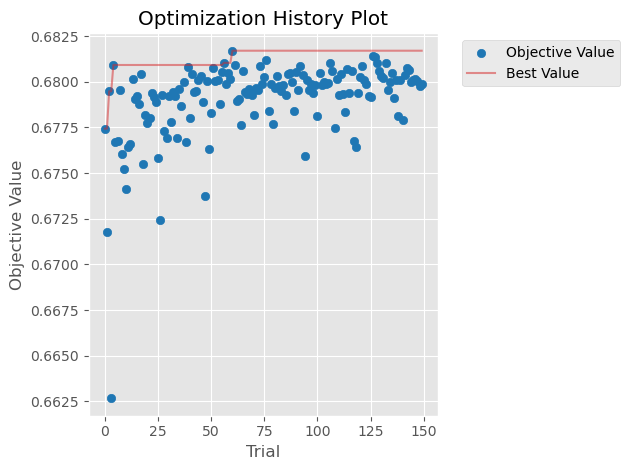

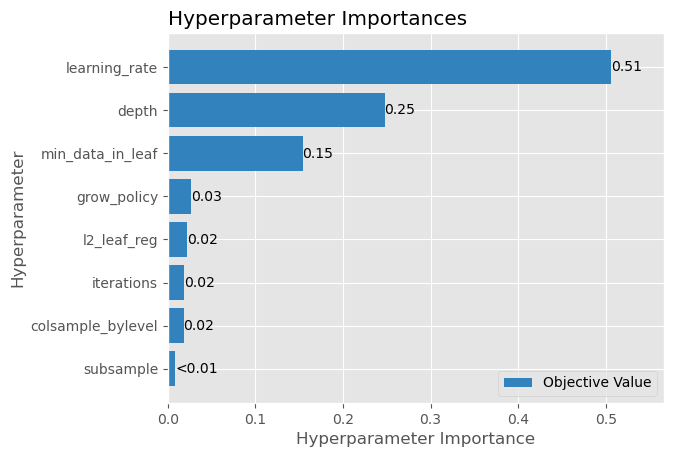

In [5]:
catb_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='CatBoostClassifier'
)

catb_study.optimize(
    lambda trial: objective_catboost(trial, X_main, y_main),
    n_trials=150,
    show_progress_bar=True
)

catb_best_params = catb_study.best_params.copy()
print(f"Лучший ROC-AUC: {catb_study.best_value:.4f}")
print(catb_best_params)

optuna.visualization.matplotlib.plot_optimization_history(catb_study)
optuna.visualization.matplotlib.plot_param_importances(catb_study)

In [6]:
xgb_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='XGBClassifier'
)

xgb_study.optimize(
    lambda trial: objective_xgb(trial, X_main, y_main),
    n_trials=150,
    show_progress_bar=True
)

xgb_best_params = xgb_study.best_params.copy()
print(f"Лучший ROC-AUC: {xgb_study.best_value:.4f}")
print(xgb_best_params)

[I 2026-07-01 22:00:24,853] A new study created in memory with name: XGBClassifier


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-07-01 22:00:32,056] Trial 0 finished with value: 0.6576656270384326 and parameters: {'n_estimators': 1000, 'learning_rate': 0.03968793330444373, 'max_depth': 4, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 3.9676050770529883, 'reg_lambda': 0.6358358856676253}. Best is trial 0 with value: 0.6576656270384326.
[I 2026-07-01 22:00:41,410] Trial 1 finished with value: 0.6339749422405252 and parameters: {'n_estimators': 1500, 'learning_rate': 0.06798962421591129, 'max_depth': 4, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0.08179499475211674, 'reg_lambda': 0.3752055855124282}. Best is trial 0 with value: 0.6576656270384326.
[I 2026-07-01 22:00:53,329] Trial 2 finished with value: 0.6543515957710431 and parameters: {'n_estimators': 1500, 'learning_rate': 0.013787764619353767, 'max_depth': 5, 'subsample': 0.6831809216468459, 'colsample_bytree': 0.728034992108518, 'reg_alpha': 2.267398652378039, 'reg_lamb

In [7]:
lgbm_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='LGBMClassifier'
)

lgbm_study.optimize(
    lambda trial: objective_lgbm(trial, X_main, y_main),
    n_trials=150,
    show_progress_bar=True
)

lgbm_best_params = lgbm_study.best_params.copy()
print(f"Лучший ROC-AUC: {lgbm_study.best_value:.4f}")
print(lgbm_best_params)

[I 2026-07-01 22:12:14,076] A new study created in memory with name: LGBMClassifier


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-07-01 22:12:17,085] Trial 0 finished with value: 0.6524701424219378 and parameters: {'n_estimators': 1000, 'learning_rate': 0.03968793330444373, 'max_depth': 4, 'num_leaves': 32, 'subsample': 0.5290418060840998, 'colsample_bytree': 0.9330880728874675, 'reg_alpha': 0.6358358856676253, 'reg_lambda': 1.3311216080736887}. Best is trial 0 with value: 0.6524701424219378.
[I 2026-07-01 22:12:19,678] Trial 1 finished with value: 0.6676154983643914 and parameters: {'n_estimators': 1000, 'learning_rate': 0.016305687346221478, 'max_depth': 4, 'num_leaves': 35, 'subsample': 0.6521211214797689, 'colsample_bytree': 0.762378215816119, 'reg_alpha': 0.19762189340280073, 'reg_lambda': 0.07476312062252301}. Best is trial 1 with value: 0.6676154983643914.
[I 2026-07-01 22:12:22,059] Trial 2 finished with value: 0.6608414425983924 and parameters: {'n_estimators': 500, 'learning_rate': 0.023246728489504348, 'max_depth': 6, 'num_leaves': 103, 'subsample': 0.5998368910791798, 'colsample_bytree': 0.757

In [8]:
oof_results = compute_oof_ensemble(
    X_main, y_main,
    catb_params=catb_best_params,
    xgb_params=xgb_best_params,
    lgbm_params=lgbm_best_params,
)

OOF CatBoost:  0.68108
OOF XGBoost:   0.67700
OOF LightGBM:  0.67649
OOF Ensemble:  0.67950


In [11]:
import numpy as np
catb_final, xgb_final, lgbm_final = train_final_models(
    X_main, y_main,
    catb_params=catb_best_params,
    xgb_params=xgb_best_params,
    lgbm_params=lgbm_best_params,
    avg_best_iterations=int(np.mean(oof_results['best_iterations_catb'])),
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

=== CatBoost ===
Classification report:
              precision    recall  f1-score   support

           0       0.45      0.63      0.52       407
           1       0.84      0.72      0.77      1112

    accuracy                           0.69      1519
   macro avg       0.64      0.67      0.65      1519
weighted avg       0.73      0.69      0.71      1519

ROC-AUC: 0.7490034999027805


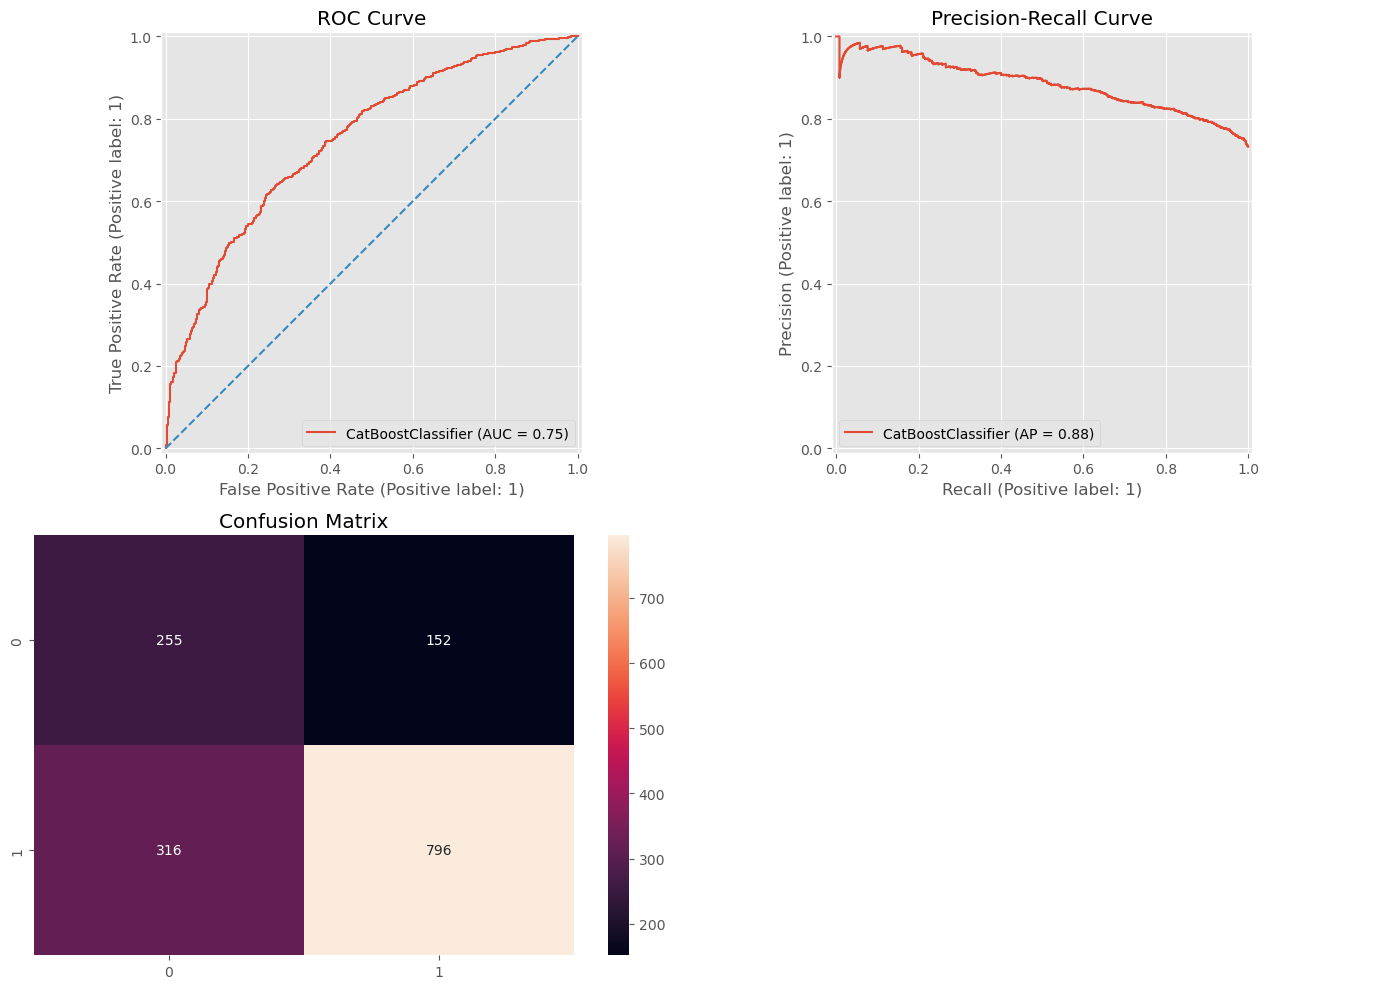

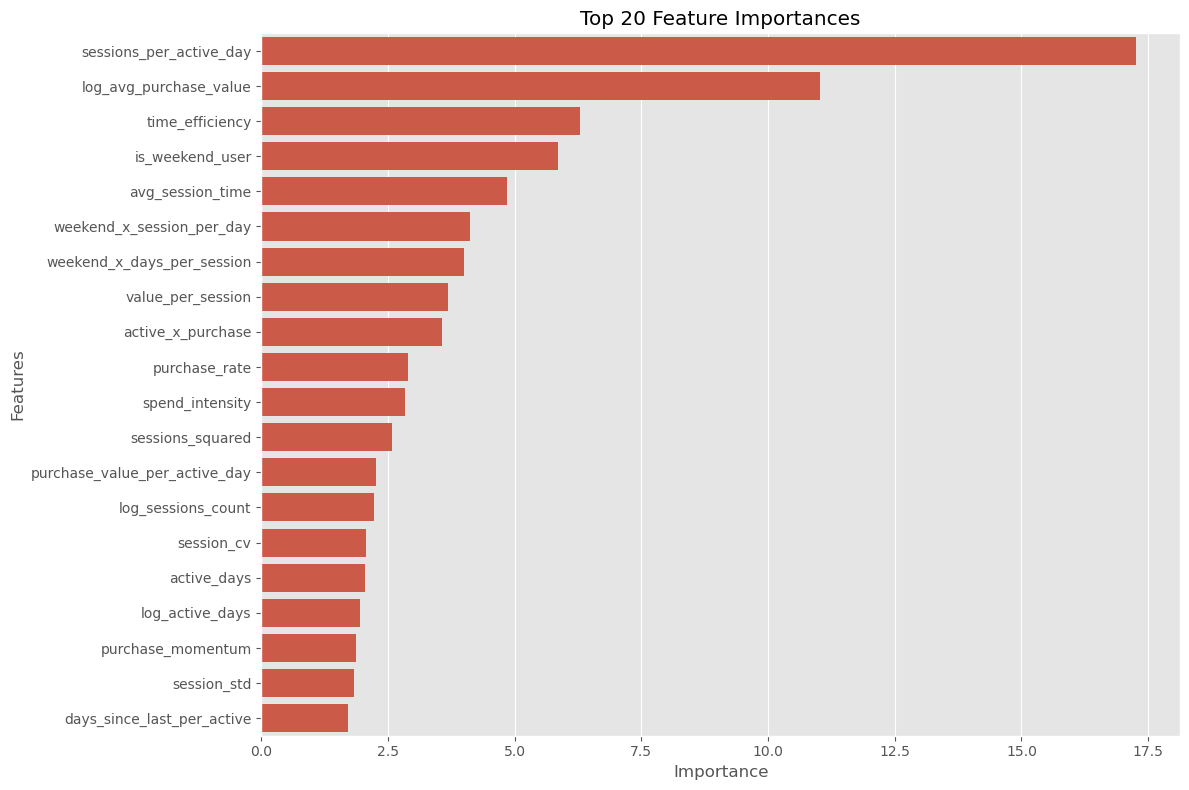

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_main, y_main, test_size=0.2, random_state=RANDOM_STATE, stratify=y_main
)

# Оценка CatBoost
print("=== CatBoost ===")
metrics_report(catb_final, X_test, y_test)

# Важность признаков
plot_feature_importance(catb_final, X_main.columns.tolist())

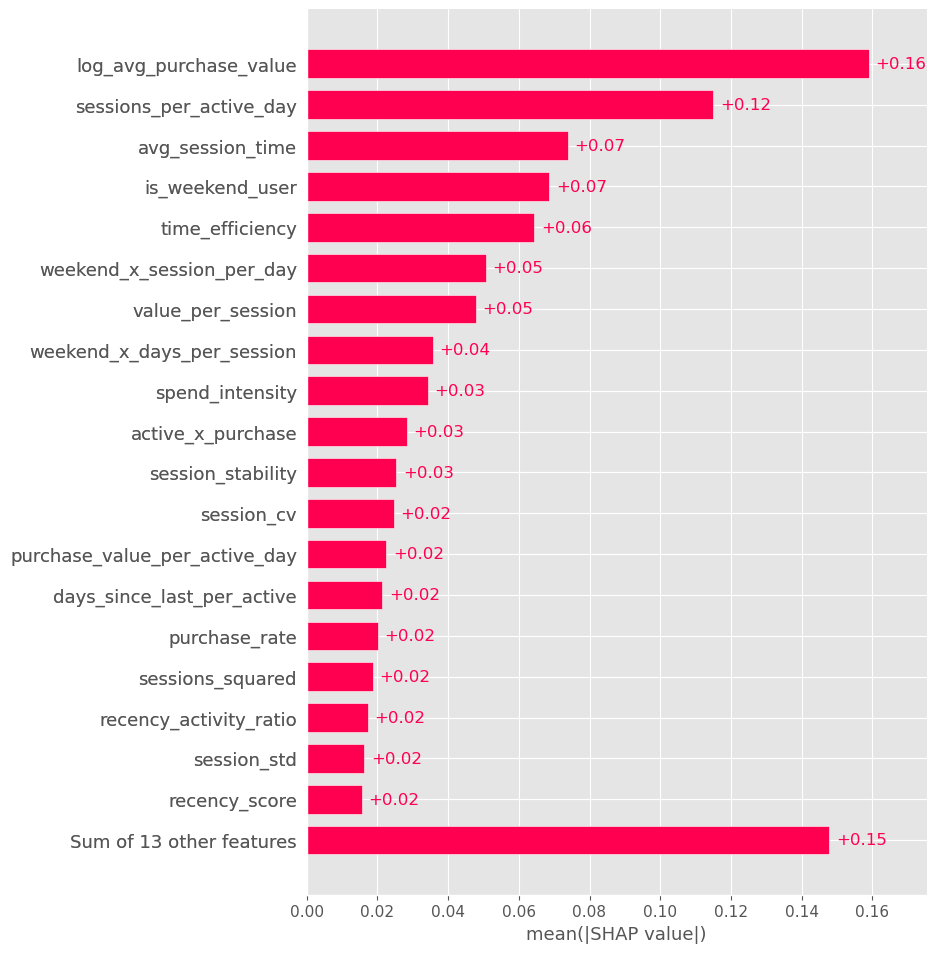

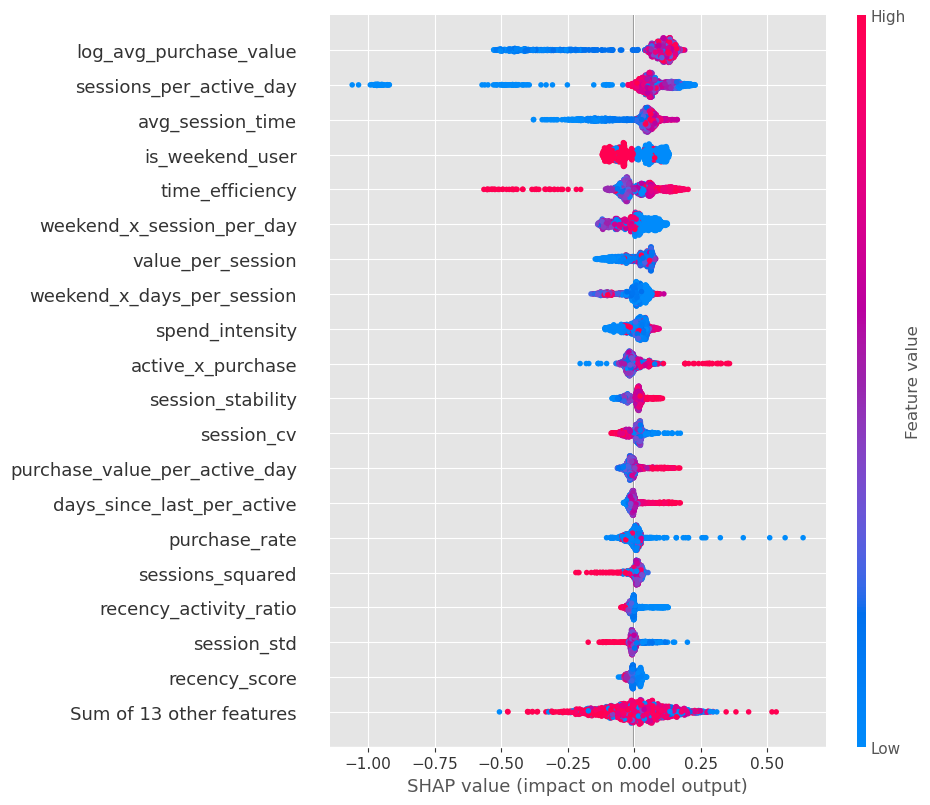

In [13]:
X_sample = X_test.sample(n=1500, random_state=RANDOM_STATE)
shap_explainer = shap.TreeExplainer(model=catb_final)
shap_values = shap_explainer.shap_values(X_sample)

explanation = shap.Explanation(
    values=shap_values,
    base_values=shap_explainer.expected_value,
    data=X_sample,
    feature_names=X_sample.columns.tolist()
)

shap.plots.bar(explanation, max_display=20)
shap.plots.beeswarm(explanation, max_display=20)

In [14]:
# Одиночная модель
make_submission(catb_final, df_test, add_features, 'submission_single.csv')

# Ансамбль
make_submission_ensemble(
    [catb_final, xgb_final, lgbm_final],
    df_test,
    add_features,
    'submission_ensemble.csv'
)

Сохранено: submission_single.csv (2532 строк)
     id  retention
0  7001   0.497906
1  1319   0.456238
2  8901   0.574454
3  9175   0.524499
4   350   0.657504
Сохранено: submission_ensemble.csv (2532 строк)
     id  retention
0  7001   0.670496
1  1319   0.601942
2  8901   0.705180
3  9175   0.675077
4   350   0.770859


,id,retention
0,7001,0.670496
1,1319,0.601942
2,8901,0.705180
3,9175,0.675077
4,350,0.770859
...,...,...
2527,3505,0.790555
2528,3468,0.708873
2529,3726,0.822252
2530,110,0.760943


In [15]:
save_models({
    'catboost': catb_final,
    'xgboost': xgb_final,
    'lightgbm': lgbm_final,
}, directory='models/')

Модель сохранена: models/catboost.pkl
Модель сохранена: models/xgboost.pkl
Модель сохранена: models/lightgbm.pkl
